In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df_train = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')
df_sample = pd.read_csv('./data/sample_submission.csv')
df_train.head()

,date_1,day,month,year,temp2(c),temp2_max(c),temp2_min(c),temp2_ave(c),suface_pressure(pa),wind_speed50_max(m/s),wind_speed50_min(m/s),wind_speed50_ave(m/s),prectotcorr,total_demand(mw),date_2,max_generation(mw)
0,01-01-18,1,1,2018,19.11,24.48,13.78,19.130,101.08,5.05,0.23,2.640,0.00,8000.0,1/1/2018,7651.0
1,02-01-18,2,1,2018,18.24,23.16,15.28,19.220,100.94,6.20,1.59,3.895,0.01,7900.0,2/1/2018,7782.0
2,03-01-18,3,1,2018,15.78,22.65,11.52,17.085,101.12,6.96,3.64,5.300,0.17,7900.0,3/1/2018,7707.0
3,04-01-18,4,1,2018,13.78,20.32,8.19,14.255,101.34,5.91,1.54,3.725,0.34,8000.0,4/1/2018,7715.0
4,05-01-18,5,1,2018,13.87,20.79,8.24,14.515,101.17,6.02,3.09,4.555,0.00,7200.0,5/1/2018,6926.0


In [4]:
df_train.tail()

,date_1,day,month,year,temp2(c),temp2_max(c),temp2_min(c),temp2_ave(c),suface_pressure(pa),wind_speed50_max(m/s),wind_speed50_min(m/s),wind_speed50_ave(m/s),prectotcorr,total_demand(mw),date_2,max_generation(mw)
1357,19-09-21,19,9,2021,27.40,30.18,25.33,27.755,100.62,4.62,0.73,2.675,21.21,11833.0,19-09-21,12370.0
1358,20-09-21,20,9,2021,26.84,29.23,25.02,27.125,100.56,5.47,3.07,4.270,3.36,11926.0,20-09-21,12571.0
1359,21-09-21,21,9,2021,26.87,29.71,24.97,27.340,100.49,5.99,3.33,4.660,3.54,11898.0,21-09-21,12403.0
1360,22-09-21,22,9,2021,26.35,29.05,24.74,26.895,100.42,5.62,3.60,4.610,5.79,11955.0,22-09-21,12491.0
1361,23-09-21,23,9,2021,28.10,31.86,24.81,28.335,100.55,6.33,1.82,4.075,4.79,12472.0,23-09-21,NaN


In [5]:
df_train.shape

(1362, 16)

In [6]:
df_train.columns

Index(['date_1', 'day', 'month', 'year', 'temp2(c)', 'temp2_max(c)',
       'temp2_min(c)', 'temp2_ave(c)', 'suface_pressure(pa)',
       'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)',
       'wind_speed50_ave(m/s)', 'prectotcorr', 'total_demand(mw)', 'date_2',
       'max_generation(mw)'],
      dtype='object')

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_1                 1362 non-null   object 
 1   day                    1362 non-null   int64  
 2   month                  1362 non-null   int64  
 3   year                   1362 non-null   int64  
 4   temp2(c)               1362 non-null   float64
 5   temp2_max(c)           1362 non-null   float64
 6   temp2_min(c)           1362 non-null   float64
 7   temp2_ave(c)           1362 non-null   float64
 8   suface_pressure(pa)    1362 non-null   float64
 9   wind_speed50_max(m/s)  1362 non-null   float64
 10  wind_speed50_min(m/s)  1362 non-null   float64
 11  wind_speed50_ave(m/s)  1362 non-null   float64
 12  prectotcorr            1362 non-null   float64
 13  total_demand(mw)       1343 non-null   float64
 14  date_2                 1362 non-null   object 
 15  max_

In [8]:
df_train.describe()

,day,month,year,temp2(c),temp2_max(c),temp2_min(c),temp2_ave(c),suface_pressure(pa),wind_speed50_max(m/s),wind_speed50_min(m/s),wind_speed50_ave(m/s),prectotcorr,total_demand(mw),max_generation(mw)
count,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1343.000000,1339.000000
mean,15.664464,6.207783,2019.391336,25.533722,30.168906,21.444383,25.806645,100.679838,5.842606,2.392100,4.117353,7.305228,10133.462398,10180.060493
std,8.783696,3.352014,1.079642,4.587751,4.059739,5.636870,4.517398,0.585237,1.984891,1.688897,1.685834,12.038254,1527.238089,1611.880670
min,1.000000,1.000000,2018.000000,12.800000,17.800000,6.430000,13.040000,99.030000,1.470000,0.020000,0.780000,0.000000,6108.000000,4855.000000
25%,8.000000,3.000000,2018.000000,22.585000,27.980000,17.182500,22.837500,100.190000,4.450000,1.020000,2.840000,0.000000,8800.000000,8866.500000
50%,16.000000,6.000000,2019.000000,27.700000,30.800000,23.735000,27.910000,100.705000,5.740000,1.975000,3.867500,2.060000,10199.000000,10093.000000
75%,23.000000,9.000000,2020.000000,28.730000,32.297500,26.200000,28.983750,101.180000,6.980000,3.610000,5.193750,9.815000,11500.000000,11503.000000
max,31.000000,12.000000,2021.000000,33.330000,41.960000,27.920000,34.320000,101.840000,21.300000,10.610000,14.425000,98.610000,13194.000000,13792.000000


## EDA

In [9]:
df_train['date_1'] = pd.to_datetime(df_train['date_1'], format='%d-%m-%y')
df_test['date_1'] = pd.to_datetime(df_test['date_1'], format='%d-%m-%y')

In [10]:
missing_values = df_train.isnull().sum()
print("Missing values:\n", missing_values[missing_values > 0])

Missing values:
 total_demand(mw)      19
max_generation(mw)    23
dtype: int64


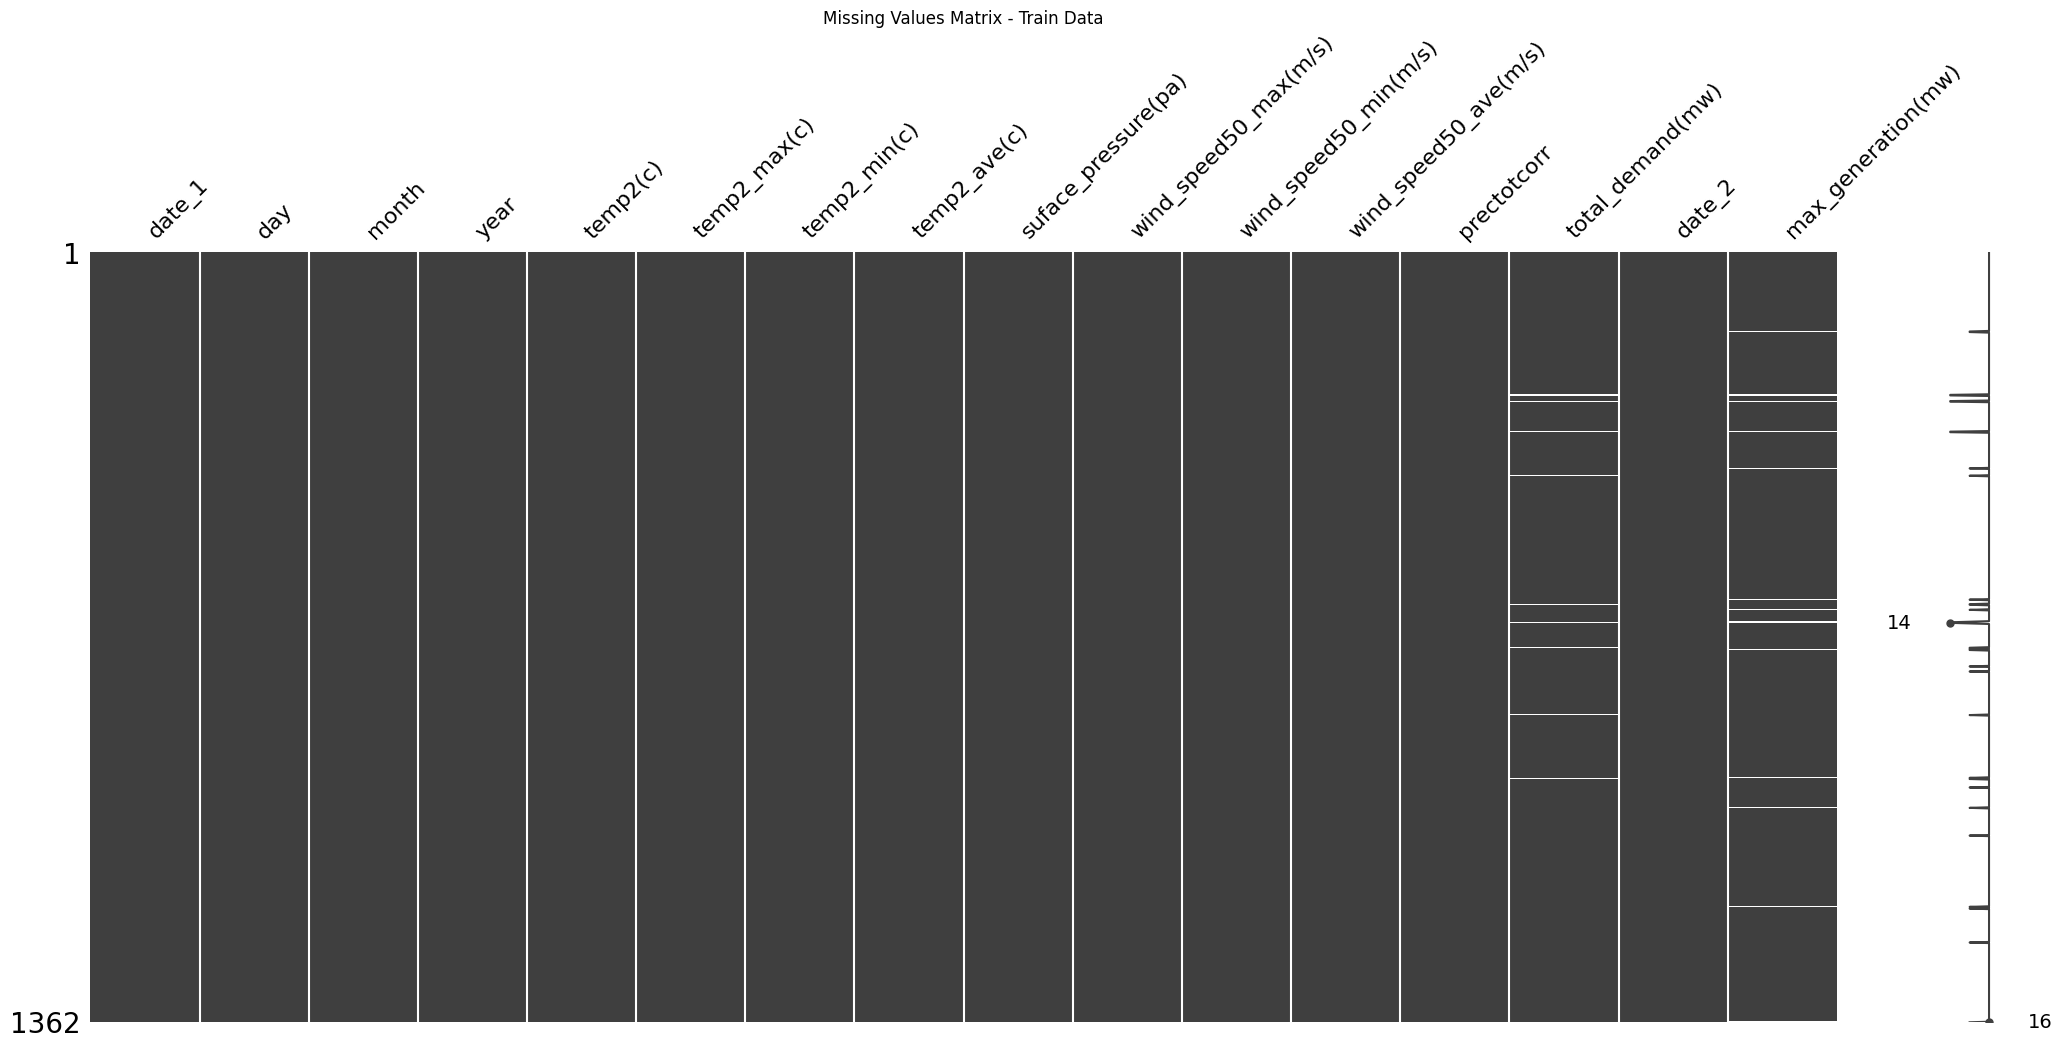

In [11]:
msno.matrix(df_train)
plt.title("Missing Values Matrix - Train Data")
plt.show()

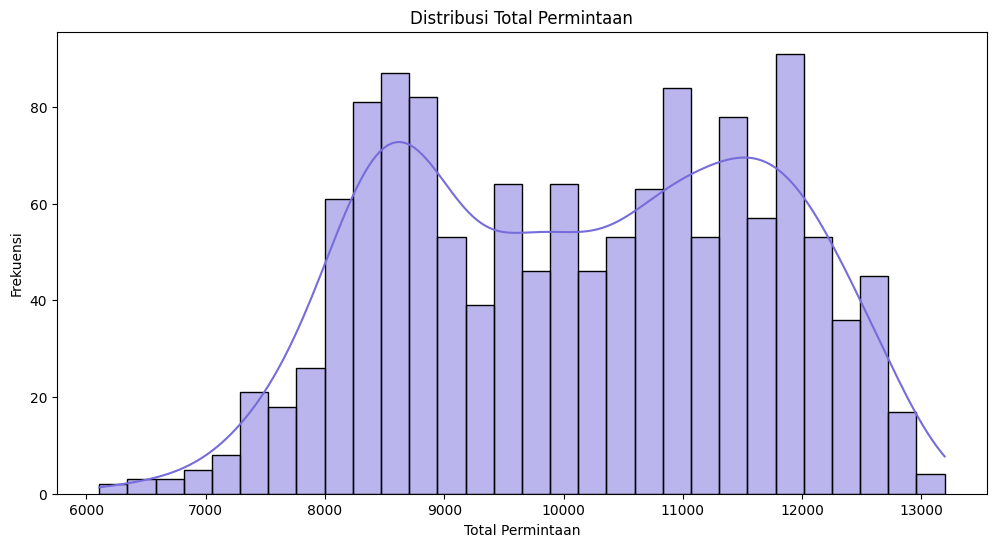

In [12]:
plt.figure(figsize=(12, 6))
sns.histplot(df_train['total_demand(mw)'], bins=30, kde=True, color='#766CDB')
plt.title('Distribusi Total Permintaan')
plt.xlabel('Total Permintaan')
plt.ylabel('Frekuensi')
plt.show()

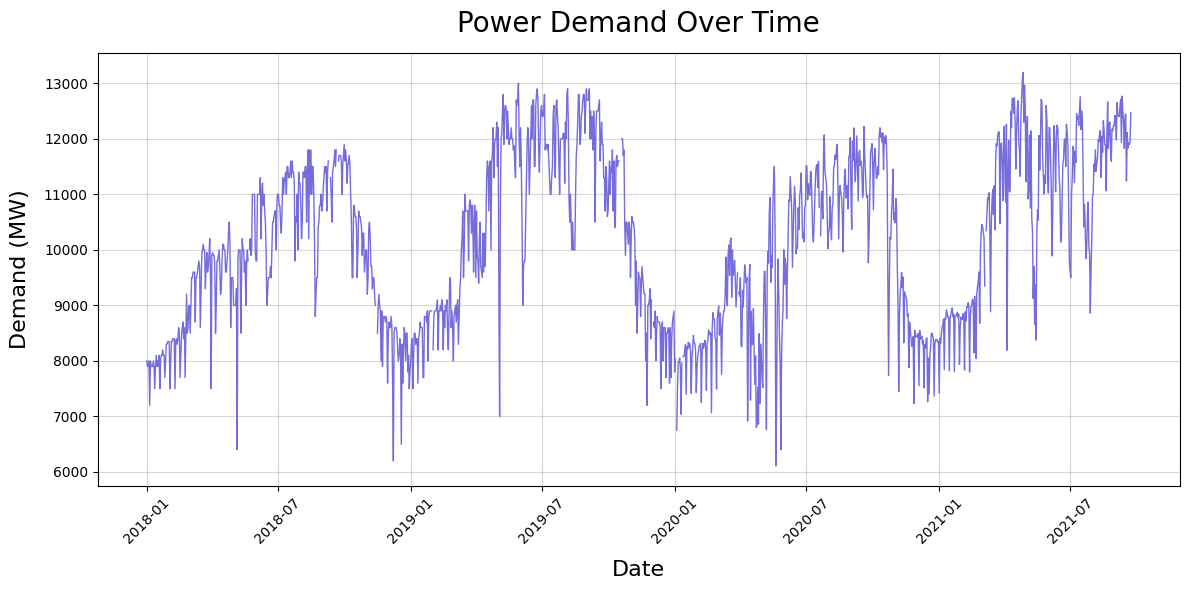

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df_train['date_1'], df_train['total_demand(mw)'], linewidth=1, color='#766CDB')
plt.title('Power Demand Over Time', pad=15, fontsize=20)
plt.xlabel('Date', labelpad=10, fontsize=16)
plt.ylabel('Demand (MW)', labelpad=10, fontsize=16)
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

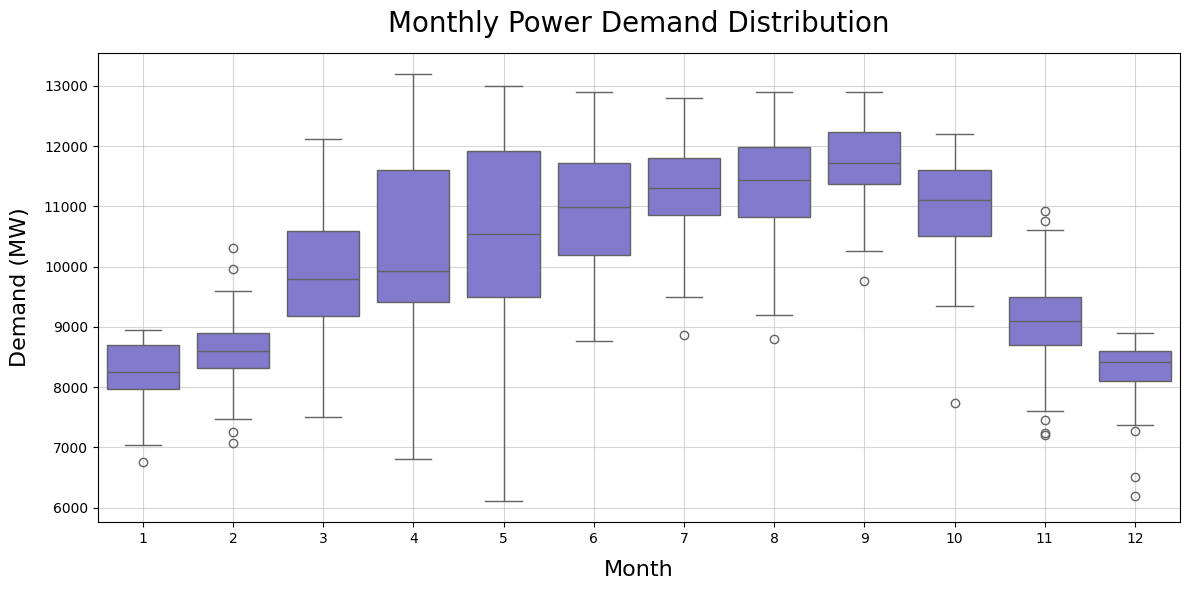

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train, x='month', y='total_demand(mw)', color='#766CDB')
plt.title('Monthly Power Demand Distribution', pad=15, fontsize=20)
plt.xlabel('Month', labelpad=10, fontsize=16)
plt.ylabel('Demand (MW)', labelpad=10, fontsize=16)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

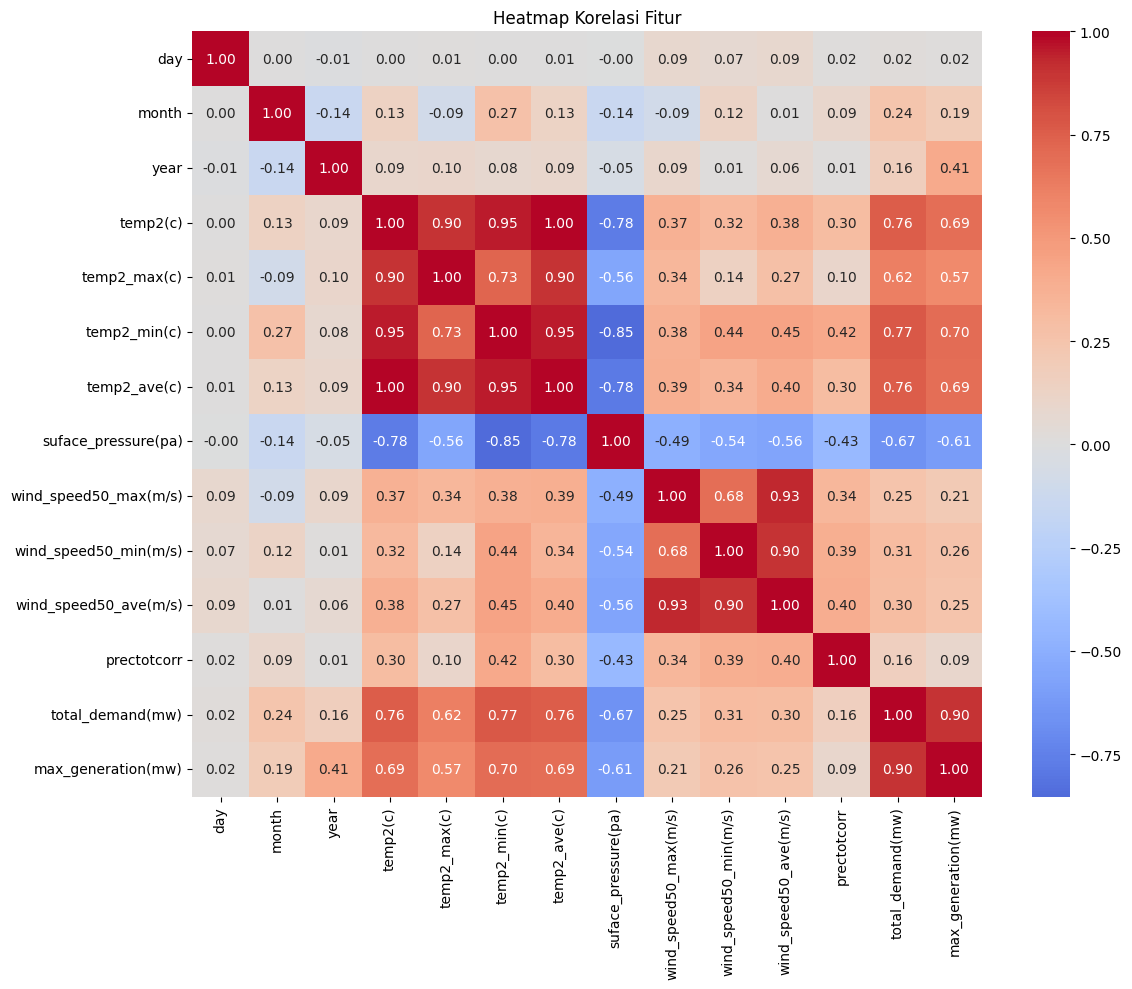

In [15]:
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Heatmap Korelasi Fitur")
plt.tight_layout()
plt.show()

## Handle missing value

In [ ]:
df_train['total_demand(mw)'] = df_train['total_demand(mw)'].interpolate(method='linear')
df_train['max_generation(mw)'] = df_train['max_generation(mw)'].interpolate(method='linear')

print(df_train[['total_demand(mw)', 'max_generation(mw)']].isnull().sum())

total_demand(mw)      0
max_generation(mw)    0
dtype: int64


In [ ]:
df_train['day_of_week'] = df_train['date_1'].dt.dayofweek
df_train['is_weekend'] = df_train['day_of_week'].isin([5,6]).astype(int)
df_train['season'] = pd.cut(df_train['month'], bins=[0,3,6,9,12], labels=['Winter','Spring','Summer','Fall'])

In [ ]:
df_train['demand_lag1'] = df_train['total_demand(mw)'].shift(1)
df_train['demand_lag7'] = df_train['total_demand(mw)'].shift(7)

In [ ]:
df_train['temp_range'] = df_train['temp2_max(c)'] - df_train['temp2_min(c)']

In [ ]:
features = ['temp2(c)', 'temp2_max(c)', 'temp2_min(c)', 'temp2_ave(c)', 'suface_pressure(pa)', 'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)', 'wind_speed50_ave(m/s)', 'temp_range']

scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])

In [ ]:
print("Final dataset shape:", df_train.shape)
print("Feature list:")
print(df_train.columns.tolist())

Final dataset shape: (1362, 22)
Feature list:
['date_1', 'day', 'month', 'year', 'temp2(c)', 'temp2_max(c)', 'temp2_min(c)', 'temp2_ave(c)', 'suface_pressure(pa)', 'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)', 'wind_speed50_ave(m/s)', 'prectotcorr', 'total_demand(mw)', 'date_2', 'max_generation(mw)', 'day_of_week', 'is_weekend', 'season', 'demand_lag1', 'demand_lag7', 'temp_range']


## Models

In [ ]:
features = ['temp2(c)', 'temp2_max(c)', 'temp2_min(c)', 'temp2_ave(c)', 
           'suface_pressure(pa)', 'wind_speed50_max(m/s)', 'wind_speed50_min(m/s)', 
           'wind_speed50_ave(m/s)', 'prectotcorr', 'day_of_week', 'is_weekend',
           'demand_lag1', 'demand_lag7', 'temp_range']

In [ ]:
X = df_train[features]
y = df_train['total_demand(mw)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

In [ ]:
print(df_train.isnull().sum())

date_1                   0
day                      0
month                    0
year                     0
temp2(c)                 0
temp2_max(c)             0
temp2_min(c)             0
temp2_ave(c)             0
suface_pressure(pa)      0
wind_speed50_max(m/s)    0
wind_speed50_min(m/s)    0
wind_speed50_ave(m/s)    0
prectotcorr              0
total_demand(mw)         0
date_2                   0
max_generation(mw)       0
day_of_week              0
is_weekend               0
season                   0
demand_lag1              1
demand_lag7              7
temp_range               0
dtype: int64


In [ ]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAPE': mape * 100, 
        'RMSE': rmse,
        'R2': r2
    }

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
for model_name, metrics in results.items():
    print(f"\
{model_name}:")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"R2: {metrics['R2']:.3f}")

In [ ]:
model = min(results.items(), key=lambda x: x[1]['MAPE'])[0]
best_model = models[model]
y_pred = best_model.predict(X_test)

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#766CDB')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', color='#DA847C')
plt.xlabel('Actual Demand (MW)', fontsize=16, labelpad=10)
plt.ylabel('Predicted Demand (MW)', fontsize=16, labelpad=10)
plt.title(f'Actual vs Predicted Demand\
{model} Model', pad=15, fontsize=20)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
if 'Random Forest' in models:
    importance = pd.DataFrame({
        'feature': features,
        'importance': models['Random Forest'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance.head(10), x='importance', y='feature', palette=['#766CDB'])
    plt.title('Top 10 Feature Importance\
Random Forest Model', pad=15, fontsize=20)
    plt.xlabel('Importance', fontsize=16, labelpad=10)
    plt.ylabel('Feature', fontsize=16, labelpad=10)
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()